In [2]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']
flavors = ['SNACKPACK_CHOCOLATE', 'SNACKPACK_VANILLA', 'SNACKPACK_PISTACHIO', 'SNACKPACK_STRAWBERRY', 'SNACKPACK_RASPBERRY']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if row['product'] not in flavors or not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

del price_rows
del offset
del col
del day
del f
del row
del mid
prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,SNACKPACK_RASPBERRY,9992,36,9990,45,,,10008,36,10010,45,,,10000.0,0.0
1,2,0,SNACKPACK_VANILLA,9992,36,9990,45,,,10008,36,10010,45,,,10000.0,0.0
2,2,0,SNACKPACK_CHOCOLATE,9992,36,9990,45,,,10008,36,10010,45,,,10000.0,0.0
3,2,0,SNACKPACK_PISTACHIO,9992,36,9990,45,,,10008,36,10010,45,,,10000.0,0.0
4,2,0,SNACKPACK_STRAWBERRY,9992,36,9990,45,,,10008,36,10010,45,,,10000.0,0.0


In [3]:
CHOCOLATE, VANILLA, PISTACHIO, STRAWBERRY, RASPBERRY = flavors

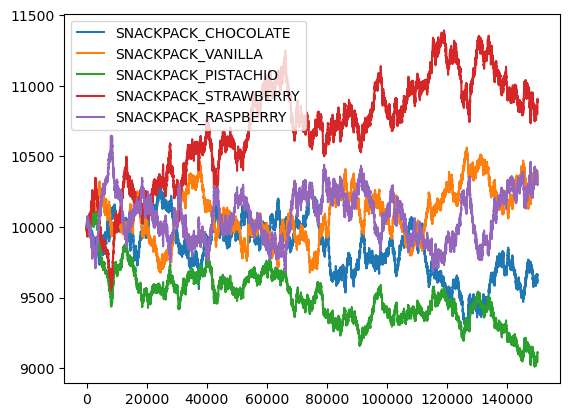

In [4]:
for p in flavors:
    plt.plot(prices[prices['product'] == p]['mid_price'], label=p)
plt.legend()
plt.show()

In [5]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

mids.head()

product,SNACKPACK_CHOCOLATE,SNACKPACK_PISTACHIO,SNACKPACK_RASPBERRY,SNACKPACK_STRAWBERRY,SNACKPACK_VANILLA
timestamp,,,,,
0,10000.0,10000.0,10000.0,10000.0,10000.0
100,10008.5,9997.5,10005.5,9994.5,9993.5
200,10007.5,10000.5,10001.5,9999.5,9994.5
300,10011.5,9999.5,10008.5,9991.5,9988.5
400,10012.5,9988.5,10018.5,9980.5,9990.5


<Axes: title={'center': 'Average mid across all SNACKPACKS'}, xlabel='timestamp'>

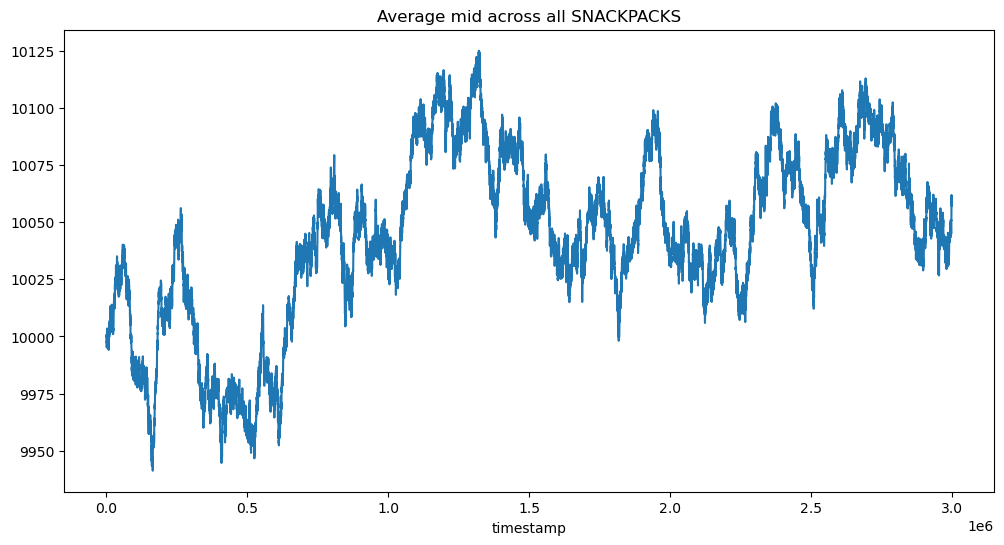

In [6]:
#plt.plot(mids["XL_XS_avg"], label="XL_XS")
#plt.plot(mids["S_L_avg"], label="S_L")
#plt.legend()
mids["SNACKPACK_avg"] = mids[flavors].mean(axis=1)
mids["SNACKPACK_avg"].plot(figsize=(12, 6), title="Average mid across all SNACKPACKS")

SNACKPACK_RASPBERRY
count    29999.000000
mean         0.010017
std          8.091750
min        -33.000000
25%         -5.500000
50%          0.000000
75%          5.500000
max         33.000000
Name: SNACKPACK_RASPBERRY, dtype: float64


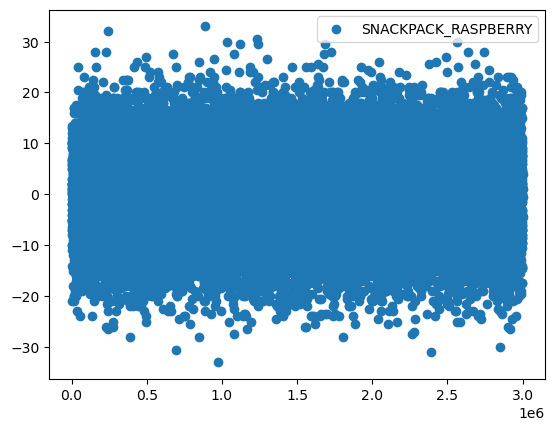

In [7]:
for p in flavors[4:5]:
    y = mids[p].diff()
    x = mids.index
    plt.scatter(x, y, label=p)
    print(p)
    print(y.describe())
plt.legend()
plt.show()

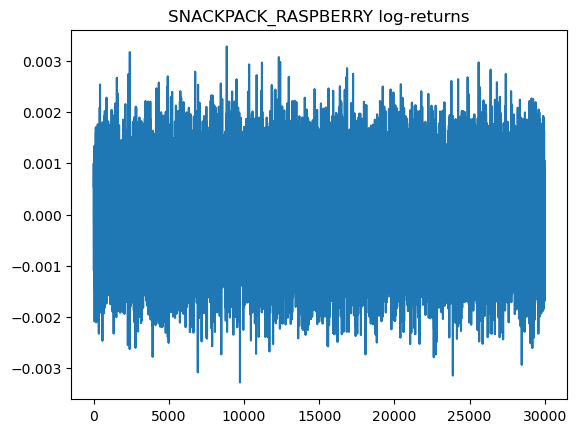

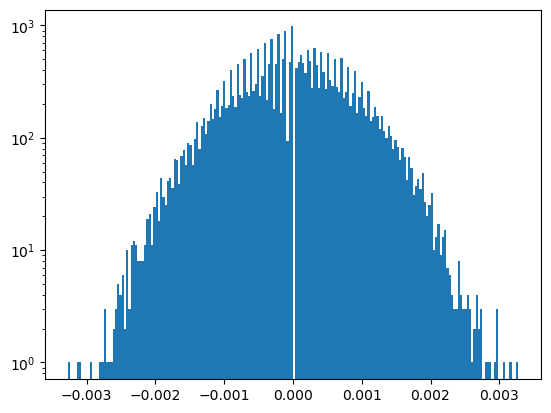

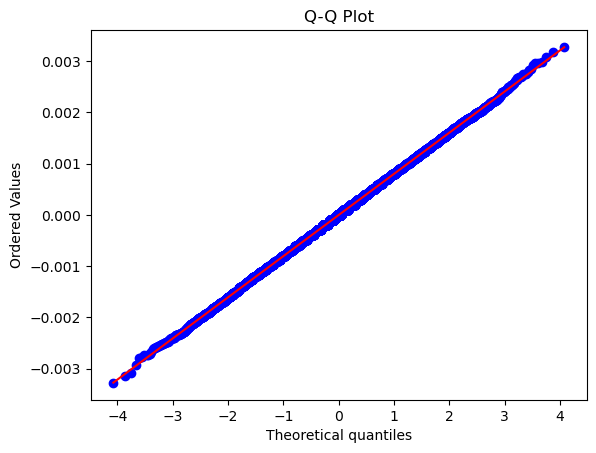

In [8]:
for s in flavors[4:5]:
    log_ret = np.diff(np.log(mids[s]))
    plt.plot(log_ret)
    plt.title(f'{s} log-returns')
    plt.show()
    # Also look at the distribution
    plt.hist(log_ret, bins=200)
    plt.yscale('log')  # log scale to see tail behavior
    plt.show()
    stats.probplot(log_ret, dist="norm", plot=plt)
    plt.title('Q-Q Plot')

In [9]:
def estimate_gbm_params(prices, dt=1.0):
    """
    prices: price level series
    dt: time step size (1.0 if returns are already per-tick)
    """
    log_ret = np.diff(np.log(prices))
    n = len(log_ret)
    
    # MLE estimates
    mu_ret = np.mean(log_ret)       # mean log-return per tick
    sigma2 = np.var(log_ret, ddof=1) # variance of log-returns
    sigma = np.sqrt(sigma2 / dt)     # volatility per unit time
    
    # Drift of the price process (Ito correction)
    mu = mu_ret / dt + 0.5 * sigma2 / dt  # drift of S, not log(S)
    
    # Standard errors
    se_mu_ret = np.sqrt(sigma2 / n)
    se_sigma = sigma / np.sqrt(2 * (n-1))
    
    # t-stat for drift being nonzero
    t_stat = mu_ret / se_mu_ret
    
    return {
        'mu_log': mu_ret,        # mean log-return per tick
        'mu': mu,                # drift of price process
        'sigma': sigma,          # volatility
        'se_mu': se_mu_ret,      # std error of mean log-return
        'se_sigma': se_sigma,    # std error of sigma
        't_stat_drift': t_stat,  # is drift significantly nonzero?
    }

for asset in flavors:
    params = estimate_gbm_params(mids[asset])
    print(f"{asset}: mu_log={params['mu_log']:.6f} "
          f"(t={params['t_stat_drift']:.2f}) "
          f"sigma={params['sigma']:.6f}")

SNACKPACK_CHOCOLATE: mu_log=-0.000001 (t=-0.30) sigma=0.000668
SNACKPACK_VANILLA: mu_log=0.000001 (t=0.29) sigma=0.000645
SNACKPACK_PISTACHIO: mu_log=-0.000003 (t=-0.97) sigma=0.000552
SNACKPACK_STRAWBERRY: mu_log=0.000003 (t=0.65) sigma=0.000761
SNACKPACK_RASPBERRY: mu_log=0.000001 (t=0.21) sigma=0.000803


# I think we get the idea at this point
It is very easy to confirm that all of these are GBMs but that none of them have statistically significant drift terms. Therefore all the strategies must rely on lags or correlation or statarb

In [10]:
from statsmodels.tsa.stattools import coint
import itertools

for a1, a2 in itertools.combinations(flavors, 2):
    pval = coint(mids[a1], mids[a2])[1]
    print(f"{a1} vs {a2}: p={pval:.4f}")
    # p < 0.05 means cointegrated → pairs trade

SNACKPACK_CHOCOLATE vs SNACKPACK_VANILLA: p=0.6379
SNACKPACK_CHOCOLATE vs SNACKPACK_PISTACHIO: p=0.0453
SNACKPACK_CHOCOLATE vs SNACKPACK_STRAWBERRY: p=0.0356
SNACKPACK_CHOCOLATE vs SNACKPACK_RASPBERRY: p=0.1857
SNACKPACK_VANILLA vs SNACKPACK_PISTACHIO: p=0.0540
SNACKPACK_VANILLA vs SNACKPACK_STRAWBERRY: p=0.0783
SNACKPACK_VANILLA vs SNACKPACK_RASPBERRY: p=0.1153
SNACKPACK_PISTACHIO vs SNACKPACK_STRAWBERRY: p=0.0313
SNACKPACK_PISTACHIO vs SNACKPACK_RASPBERRY: p=0.3371
SNACKPACK_STRAWBERRY vs SNACKPACK_RASPBERRY: p=0.3638


According to the test above, we have statistical evidence of the following cointegrations
- CHOCOLATE VS PISTACHIO
- CHOCOLATE VS STRAWBERRY
- PISTACHIO VS STRAWBERRY

In [11]:
import numpy as np
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

def find_cointegration_vector(p1, p2, name1, name2):
    # Regress p1 on p2 to find beta
    X = sm.add_constant(p2)
    model = sm.OLS(p1, X).fit()
    beta = model.params.iloc[1]
    intercept = model.params.iloc[0]
    
    # The spread should be stationary
    spread = p1 - beta * p2 - intercept
    adf_pval = adfuller(spread)[1]
    
    print(f"{name1} = {beta:.4f} * {name2} + {intercept:.4f}")
    print(f"Spread ADF p-value: {adf_pval:.4f}")
    print(f"Spread mean: {spread.mean():.4f}, std: {spread.std():.4f}")
    
    return beta, intercept, spread

# Find each pair
b_cp, i_cp, spread_cp = find_cointegration_vector(
    mids[CHOCOLATE], mids[PISTACHIO],
    'CHOCOLATE', 'PISTACHIO'
)
b_cs, i_cs, spread_cs = find_cointegration_vector(
    mids[CHOCOLATE], mids[STRAWBERRY],
    'CHOCOLATE', 'STRAWBERRY'
)
b_ps, i_ps, spread_ps = find_cointegration_vector(
    mids[PISTACHIO], mids[STRAWBERRY],
    'PISTACHIO', 'STRAWBERRY'
)

CHOCOLATE = 0.5037 * PISTACHIO + 5060.7568
Spread ADF p-value: 0.0119
Spread mean: -0.0000, std: 177.1338
CHOCOLATE = -0.2987 * STRAWBERRY + 13041.5713
Spread ADF p-value: 0.0089
Spread mean: -0.0000, std: 168.8167
PISTACHIO = -0.2275 * STRAWBERRY + 11932.0960
Spread ADF p-value: 0.0077
Spread mean: 0.0000, std: 168.2563


In [12]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

price_matrix = np.column_stack([
    mids[CHOCOLATE],
    mids[PISTACHIO], 
    mids[STRAWBERRY]
])

result = coint_johansen(price_matrix, det_order=0, k_ar_diff=1)

print("Eigenvalues:", result.eig)
print("Cointegrating vectors (columns):")
print(result.evec)
print("Trace statistic:", result.lr1)
print("Critical values (90%, 95%, 99%):", result.cvt)

Eigenvalues: [0.00061782 0.00051405 0.00023198]
Cointegrating vectors (columns):
[[ 0.00289199 -0.00483549 -0.0026483 ]
 [-0.00614811 -0.00076955 -0.00079968]
 [-0.00067093 -0.00300161  0.00140155]]
Trace statistic: [40.92309595 22.38410506  6.95977308]
Critical values (90%, 95%, 99%): [[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [13]:
# Compute spread
beta = result.evec[:, 0]  # first cointegrating vector
spread = price_matrix @ beta

# Fit AR(1) to spread
from statsmodels.tsa.ar_model import AutoReg
ar_model = AutoReg(spread, lags=1).fit()
phi1 = ar_model.params[1]
mu_spread = ar_model.params[0] / (1 - phi1)
sigma_spread = np.std(ar_model.resid, ddof=2)

# Z-score for trading signal
zscore = (spread[-1] - mu_spread) / sigma_spread

# Trade: if zscore > threshold, spread is high → 
#        short the portfolio with weights beta
# If zscore < -threshold, spread is low → 
#        long the portfolio with weights beta

In [14]:
for asset in [CHOCOLATE, PISTACHIO, STRAWBERRY]:
    pval = adfuller(mids[asset])[1]
    print(f"{asset} ADF on levels: {pval}")

SNACKPACK_CHOCOLATE ADF on levels: 0.06774925265148915
SNACKPACK_PISTACHIO ADF on levels: 0.07807547661156136
SNACKPACK_STRAWBERRY ADF on levels: 0.1489935333536856


In [15]:
 # Renormalize so first asset has coefficient 1
beta = result.evec[:, 0]
beta_normalized = beta / beta[0]
print(f"CHOCOLATE: 1.0000")
print(f"PISTACHIO: {beta_normalized[1]:.4f}")
print(f"STRAWBERRY: {beta_normalized[2]:.4f}")

CHOCOLATE: 1.0000
PISTACHIO: -2.1259
STRAWBERRY: -0.2320


# Here's what our strat should be
We have the following model:
    $$\text{CHOCOLATE} + -2.1259 \cdot \text{PISTACHIO} + -0.2320 \cdot \text{STRAWBERRY} = Z_t$$,
where $Z_t$ is a stationary AR(1) process (we can fit the coefficients of this). Once we fit the coefficients, we know what the long-term mean should be so we can do the same mean-reversion strat we've been doing on $Z_t$.

In [16]:
print(f"  ADF on levels: {adfuller(spread)[1]:.4f}")  # should NOT reject
print(f"  ADF on log-returns: {adfuller(spread)[1]:.4f}")  # should reject
print(f"  Ljung-Box on log-returns:\n {acorr_ljungbox(spread, lags=5)}")  # should be white noise
print(f"  Hurst: {compute_Hc(spread)}")  # should be ~0.5
print(f"  Skewness of log-returns: {stats.skew(spread):.4f}")
print(f"  Excess kurtosis of log-returns: {stats.kurtosis(spread):.4f}")

  ADF on levels: 0.0050
  ADF on log-returns: 0.0050
  Ljung-Box on log-returns:
          lb_stat  lb_pvalue
1   29944.001708        0.0
2   59832.008398        0.0
3   89663.107855        0.0
4  119437.196475        0.0
5  149154.527783        0.0
  Hurst: (np.float64(0.4587958994040786), np.float64(1.683471541876691), [[10, 17, 31, 56, 100, 177, 316, 562, 1000, 1778, 3162, 5623, 10000, 17782, 30000], [np.float64(4.010096332461368), np.float64(5.469712129754786), np.float64(7.736282803748527), np.float64(10.5952893128678), np.float64(14.281205378461964), np.float64(19.565999880340005), np.float64(26.2126398723452), np.float64(35.12428336042662), np.float64(45.98481562878122), np.float64(63.013438972687), np.float64(77.44663836913317), np.float64(93.31665690624953), np.float64(109.44588476173793), np.float64(129.8058889576383), np.float64(142.63852349889885)]])
  Skewness of log-returns: -0.3035
  Excess kurtosis of log-returns: -0.1817


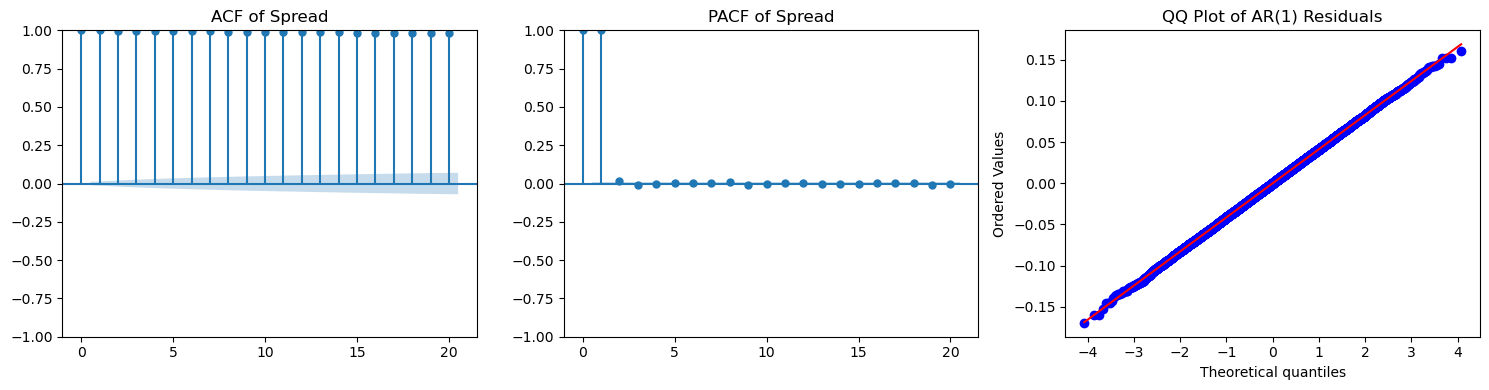

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ACF
plot_acf(spread, lags=20, ax=axes[0])
axes[0].set_title('ACF of Spread')

# PACF
plot_pacf(spread, lags=20, ax=axes[1])
axes[1].set_title('PACF of Spread')

# QQ plot of AR(1) residuals
stats.probplot(ar_model.resid, dist='norm', plot=axes[2])
axes[2].set_title('QQ Plot of AR(1) Residuals')

plt.tight_layout()
plt.show()